# Compatibilidade entre pets e prestadores: escolha de K

Este notebook documenta a escolha do numero de clusters do K-Means usado pelo endpoint `/recommend/{user_id}`. O treinamento e a inferencia compartilham o mesmo One-Hot Encoder, StandardScaler e MultiLabelBinarizers salvos em `modelo_kmeans.joblib`.

## Tratamento das variaveis e compatibilidade

- Porte, nivel de energia e raca sao categoricas e usam One-Hot Encoding.
- Peso e idade sao numericas e usam StandardScaler.
- Restricoes alimentares e comportamento sao listas; os MultiLabelBinarizers sao ajustados no treino e reutilizados na inferencia.
- O centroide e interpretado para identificar porte, energia e raca mais representativos.
- Um prestador ativo e recomendado quando atende ao porte **ou** ao nivel de energia representativo do cluster, e os cinco melhores por avaliacao sao retornados.

O vetor do pet e projetado no modelo salvo; nao se reajusta nenhum transformador durante uma chamada da API.

In [2]:
from pathlib import Path
import sys

candidatos_app = [Path.cwd().parent / 'app', Path.cwd() / 'ml-service' / 'app']
APP_DIR = next(caminho for caminho in candidatos_app if (caminho / 'features.py').exists())
ROOT_DIR = APP_DIR.parents[1]
sys.path.insert(0, str(APP_DIR))
sys.path.insert(0, str(ROOT_DIR))

from db import buscar_todos_os_pets
from features import (
    aplicar_binarizadores,
    interpretar_centroide,
    montar_matriz,
    montar_pipeline_features,
    pets_para_dataframe,
    treinar_binarizadores,
)
from train import gerar_pets_simulados

try:
    pets = buscar_todos_os_pets()
except Exception as erro:
    print(f'Banco indisponivel ({erro}); usando amostra simulada.')
    pets = []

fonte = 'banco real' if len(pets) >= 20 else 'simulado'
if len(pets) < 20:
    print(f'Apenas {len(pets)} pets reais; usando dados simulados para avaliar a pipeline.')
    pets = gerar_pets_simulados()

df = pets_para_dataframe(pets)
print(f'Fonte: {fonte}; pets para avaliar: {len(df)}')
df.head()

Apenas 1 pets reais; usando dados simulados para avaliar a pipeline.
Fonte: simulado; pets para avaliar: 60


,id,porte,nivel_energia,raca,peso_kg,idade_anos,restricoes_alimentares,comportamento
0,simulado-0,GRANDE,BAIXO,Vira-lata,33.9,0.0,[],[ansioso]
1,simulado-1,GRANDE,BAIXO,Bulldog,33.8,0.0,[],"[sociavel, brincalhao]"
2,simulado-2,PEQUENO,BAIXO,Labrador,23.7,0.0,[],[brincalhao]
3,simulado-3,PEQUENO,MEDIO,Golden Retriever,14.0,0.0,[],[brincalhao]
4,simulado-4,MEDIO,MEDIO,Labrador,11.3,0.0,[alergia a frango],[brincalhao]


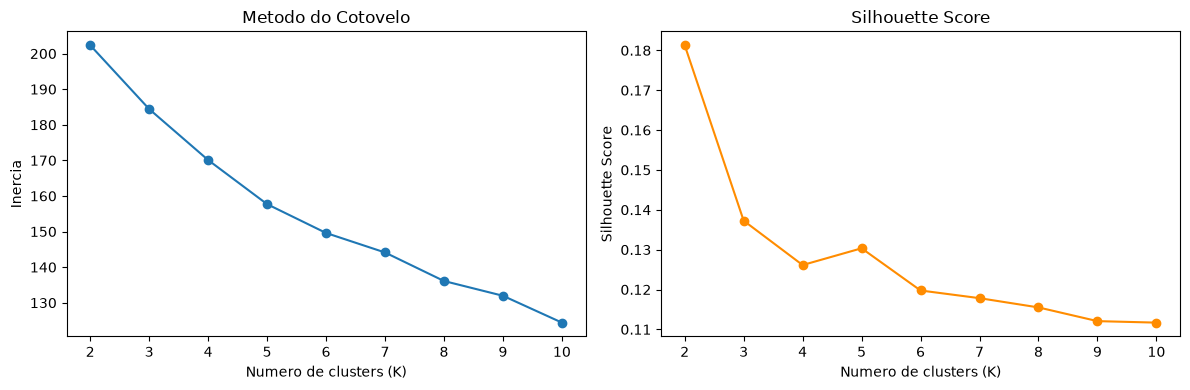

Silhouette sugere K=2 (score: 0.181)


In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pipeline_features = montar_pipeline_features()
binarizadores = treinar_binarizadores(df)
matriz = montar_matriz(df, pipeline_features, binarizadores, treinando=True)

valores_k = list(range(2, min(10, len(df) - 1) + 1))
inercias = []
silhouettes = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    rotulos = modelo.fit_predict(matriz)
    inercias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(matriz, rotulos))

figura, eixos = plt.subplots(1, 2, figsize=(12, 4))
eixos[0].plot(valores_k, inercias, marker='o')
eixos[0].set_title('Metodo do Cotovelo')
eixos[0].set_xlabel('Numero de clusters (K)')
eixos[0].set_ylabel('Inercia')
eixos[1].plot(valores_k, silhouettes, marker='o', color='darkorange')
eixos[1].set_title('Silhouette Score')
eixos[1].set_xlabel('Numero de clusters (K)')
eixos[1].set_ylabel('Silhouette Score')
figura.tight_layout()
plt.show()

melhor_k = valores_k[silhouettes.index(max(silhouettes))]
print(f'Silhouette sugere K={melhor_k} (score: {max(silhouettes):.3f})')

In [4]:
modelo_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
rotulos_finais = modelo_final.fit_predict(matriz)

for indice, centroide in enumerate(modelo_final.cluster_centers_):
    perfil = interpretar_centroide(centroide, pipeline_features)
    quantidade = int((rotulos_finais == indice).sum())
    print(f'Cluster {indice} ({quantidade} pets): {perfil}')

Cluster 0 (28 pets): {'porte': 'GRANDE', 'nivel_energia': 'MEDIO', 'raca': 'Shih Tzu'}
Cluster 1 (32 pets): {'porte': 'PEQUENO', 'nivel_energia': 'MEDIO', 'raca': 'Labrador'}


## Conclusao

A escolha automatica pelo maior Silhouette Score foi **K={{melhor_k}}**. Analise os centroides e quantidades listados acima e registre aqui a justificativa qualitativa observada nos dados reais: qual perfil de porte/energia predomina em cada grupo e por que essa separacao ajuda a recomendar prestadores.

Amostras simuladas servem apenas para validar a pipeline; a conclusao final deve ser refeita com pets reais antes da entrega.